Starting Frequency Sweep...
Training for ω₀ = 1...
  Final Loss: 1.2464e-05 | L2 Error: 3.8533e-04
Training for ω₀ = 5...
  Final Loss: 2.9073e-03 | L2 Error: 3.3840e-03
Training for ω₀ = 10...
  Final Loss: 1.6007e-01 | L2 Error: 6.7133e-03
Training for ω₀ = 15...
  Final Loss: 7.7674e+01 | L2 Error: 8.9397e-01
Training for ω₀ = 20...
  Final Loss: 9.9319e+01 | L2 Error: 9.9981e-01


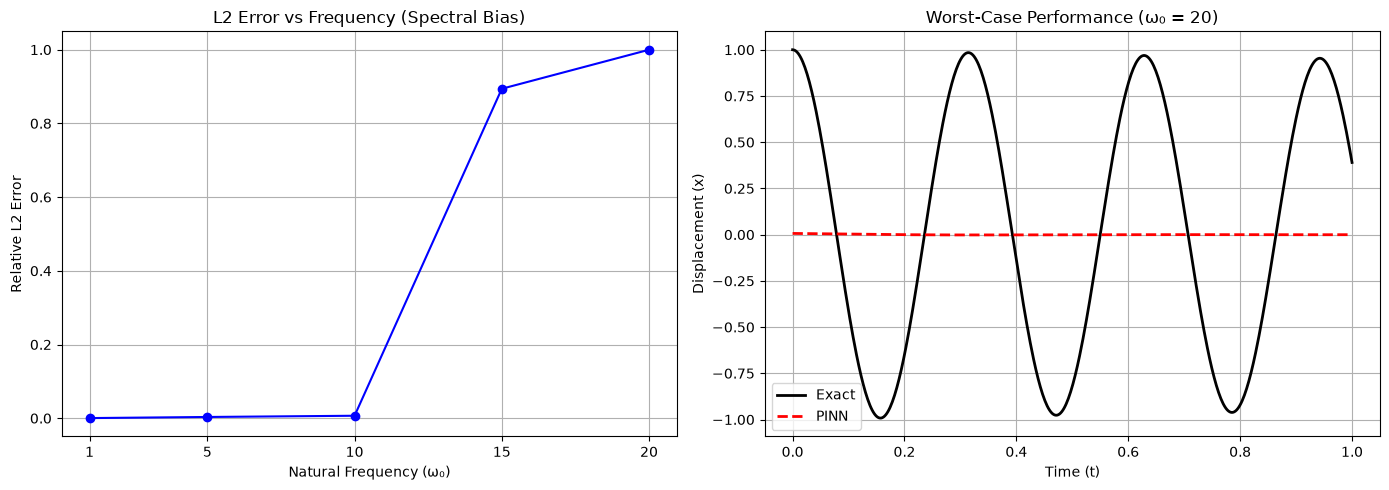

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# --- STRICT TEMPLATE ---
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
        
    def forward(self, t):
        return self.net(t)
        
    def loss(self, t_colloc, t_ic, omega):
        # PDE residual
        t_colloc.requires_grad_(True)
        x = self(t_colloc)
        x_t  = torch.autograd.grad(x.sum(), t_colloc, create_graph=True)[0]
        x_tt = torch.autograd.grad(x_t.sum(), t_colloc, create_graph=True)[0]
        
        pde_residual = x_tt + 0.1 * x_t + (omega**2) * x 
        L_pde = (pde_residual**2).mean()
        
        # Initial conditions
        # (PyTorch needs t_ic to have requires_grad=True, which we handled in the training loop)
        x0  = self(t_ic)
        x0_t = torch.autograd.grad(x0.sum(), t_ic, create_graph=True)[0]
        L_ic = (x0 - 1.0)**2 + (x0_t - 0.0)**2
        
        return L_pde + 100 * L_ic

def exact_solution(t, w0):
    """Analytical solution for the damped harmonic oscillator."""
    mu = 0.1
    delta = mu / 2.0
    w = np.sqrt(w0**2 - delta**2)
    x = np.exp(-delta * t) * (np.cos(w * t) + (delta / w) * np.sin(w * t))
    return x

def train_pinn(w0, epochs=15000):
    pinn = PINN()
    optimizer = torch.optim.Adam(pinn.parameters(), lr=1e-3)
    
    # FIX: Added .requires_grad_(True) so the template's IC derivative works
    t_colloc = torch.linspace(0, 1, 500).view(-1, 1).requires_grad_(True)
    t_ic = torch.zeros(1, 1).requires_grad_(True)
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        loss = pinn.loss(t_colloc, t_ic, w0)
        
        loss.backward()
        optimizer.step()
        
    # Evaluate
    with torch.no_grad():
        t_eval = torch.linspace(0, 1, 500).view(-1, 1)
        x_pred = pinn(t_eval).numpy().flatten()
        x_exact = exact_solution(t_eval.numpy().flatten(), w0)
        
        l2_error = np.linalg.norm(x_pred - x_exact) / np.linalg.norm(x_exact)
        final_loss = loss.item()
        
    return final_loss, l2_error, t_eval.numpy().flatten(), x_pred, x_exact

# --- Execution & Plotting ---
omega_list = [1, 5, 10, 15, 20]
results = {}

print("Starting Frequency Sweep...")
for w0 in omega_list:
    print(f"Training for ω₀ = {w0}...")
    f_loss, l2_err, t_val, x_p, x_e = train_pinn(w0)
    results[w0] = {'l2_error': l2_err, 't': t_val, 'x_pred': x_p, 'x_exact': x_e}
    print(f"  Final Loss: {f_loss:.4e} | L2 Error: {l2_err:.4e}")

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

errors = [results[w]['l2_error'] for w in omega_list]
axs[0].plot(omega_list, errors, marker='o', linestyle='-', color='b')
axs[0].set_xlabel('Natural Frequency (ω₀)')
axs[0].set_ylabel('Relative L2 Error')
axs[0].set_title('L2 Error vs Frequency (Spectral Bias)')
axs[0].set_xticks(omega_list)
axs[0].grid(True)

worst_w0 = max(results, key=lambda w: results[w]['l2_error'])
axs[1].plot(results[worst_w0]['t'], results[worst_w0]['x_exact'], 'k-', label='Exact', linewidth=2)
axs[1].plot(results[worst_w0]['t'], results[worst_w0]['x_pred'], 'r--', label='PINN', linewidth=2)
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Displacement (x)')
axs[1].set_title(f'Worst-Case Performance (ω₀ = {worst_w0})')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()